In [22]:
from geotessera import GeoTessera
import geopandas as gpd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

gt = GeoTessera()

In [26]:
tile = gpd.read_file("./dataset/tile_C51L41_WGS84.gpkg")
if tile.crs != "EPSG:4326":
    tile = tile.to_crs(epsg=4326)
bbox = list([ float(b) for b in tile.total_bounds ])
bbox

[-61.25000000000001, -8.25, -61.0, -7.999999999999998]

In [27]:
year = 2024

min_lon, min_lat, max_lon, max_lat = bbox
tiles_to_fetch = gt.registry.load_blocks_for_region(bounds = bbox, year = year)
tiles = gt.fetch_embeddings(tiles_to_fetch)
tiles

<generator object GeoTessera.fetch_embeddings at 0x77221b31f320>

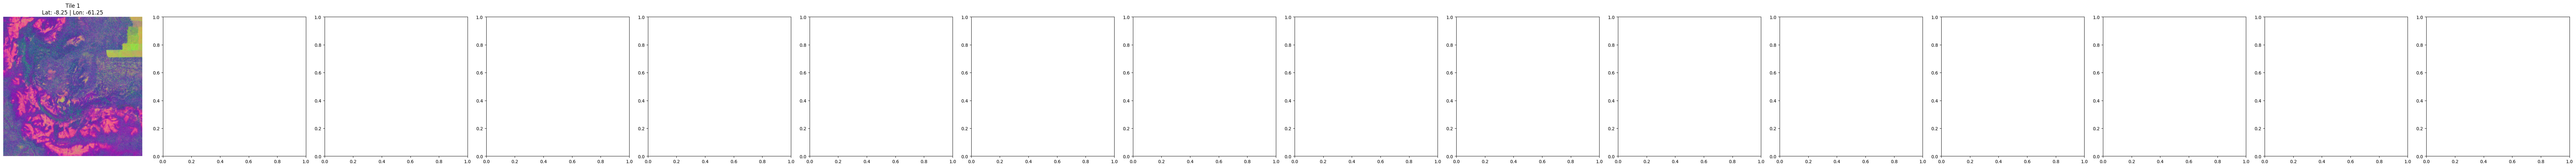

In [28]:
lista_embeddings = list(tiles)
num_tiles = len(lista_embeddings)

fig, axes = plt.subplots(1, num_tiles, figsize=(5 * num_tiles, 5))

# Garante que 'axes' seja tratável como lista mesmo se houver apenas 1 bloco
if num_tiles == 1:
    axes = [axes]

# 3. Itera sobre os blocos encontrados
for idx, (year, tile_lon, tile_lat, embedding_array, crs, transform) in enumerate(lista_embeddings):
    H, W, C = embedding_array.shape
    X_pixels = embedding_array.reshape(-1, C)

    # Redução de dimensionalidade com PCA para visualização RGB
    pca = PCA(n_components=3)
    X_pca = pca.fit_transform(X_pixels)
    img_pca = X_pca.reshape(H, W, 3)

    # Normalização dos pixels entre 0 e 1
    img_min = img_pca.min(axis=(0, 1), keepdims=True)
    img_max = img_pca.max(axis=(0, 1), keepdims=True)
    img_rgb = (img_pca - img_min) / (img_max - img_min + 1e-8)

    # Renderização do mapa
    axes[idx].imshow(img_rgb)
    axes[idx].set_title(f"Tile {idx+1}\nLat: {tile_lat:.2f} | Lon: {tile_lon:.2f}")
    axes[idx].axis("off")
    break

plt.tight_layout()
plt.show()

In [29]:
import os
import rasterio
from rasterio.transform import Affine

output_dir = "./dataset/rasters/tessera_tiles"
os.makedirs(output_dir, exist_ok=True)

# Iterate through downloaded tiles
for tile_id, (tile_arr, crs, transform) in embeddings_dict.items():
    # tile_arr shape is typically (Height, Width, 128)
    height, width, channels = tile_arr.shape
    
    # Rasterio expects shape (bands/channels, height, width)
    raster_data = tile_arr.transpose(2, 0, 1)  # shape: (128, H, W)
    
    filename = f"{output_dir}/tessera_{tile_id}_2024.tif"
    
    with rasterio.open(
        filename,
        mode="w",
        driver="GTiff",
        height=height,
        width=width,
        count=channels,            # 128 embedding dimensions
        dtype=raster_data.dtype,
        crs=crs,
        transform=transform,
        compress="lzw"             # Lossless compression to reduce file size
    ) as dst:
        dst.write(raster_data)
        
    print(f"Saved: {filename} ({channels} bands)")

AttributeError: 'list' object has no attribute 'items'